In [1]:
from sklearn.datasets import make_moons, make_circles  # the synthetic dataset
from sklearn.preprocessing import MinMaxScaler

circle_or_moons = 1  # 0 for circle, 1 for moons
n_samples = 7000  # number of sample in the dataset
noise = 0.05  # amount of noise to add in the data. Tested with 0.14 for circles 0.05 for two moons
factor = 0.4  # scale factor between the inner and the outer circle

In [2]:
if circle_or_moons == 0:
    X, Y = make_circles(n_samples=n_samples, noise=noise, factor=factor)
else:
    X, Y = make_moons(n_samples=n_samples, noise=noise)

# When working with the HKR-classifier, using labels {-1, 1} instead of {0, 1} is advised.
# This will be explained later on.
Y[Y == 1] = -1
Y[Y == 0] = 1

In [3]:
scaler = MinMaxScaler(feature_range=(0, 1))
X = scaler.fit_transform(X)

<Axes: >

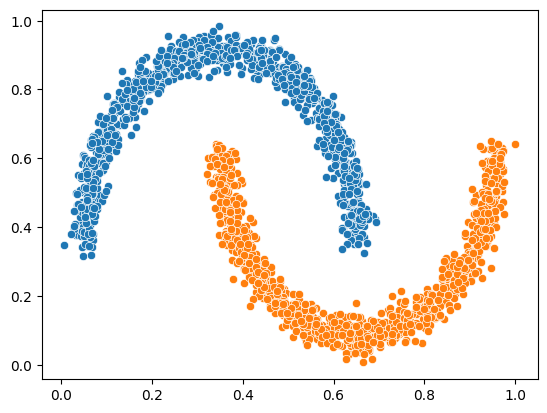

In [4]:
import seaborn as sns

X1 = X[Y == 1]
X2 = X[Y == -1]
sns.scatterplot(x=X1[:1000, 0], y=X1[:1000, 1])
sns.scatterplot(x=X2[:1000, 0], y=X2[:1000, 1])

In [5]:
import torch
import torch.nn as nn
from deel import torchlip

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Other Lipschitz activations are ReLU, MaxMin, GroupSort2, GroupSort.
wass = torchlip.Sequential(
    torchlip.SpectralLinear(2, 256),
    torchlip.GroupSort2(),
    torchlip.SpectralLinear(256, 128),
    torchlip.GroupSort2(),
    torchlip.SpectralLinear(128, 64),
    torchlip.GroupSort2(),
    torchlip.SpectralLinear(64, 1, bias=False),
).to(device)

wass

Sequential(
  (0): ParametrizedSpectralLinear(
    in_features=2, out_features=256, bias=True
    (parametrizations): ModuleDict(
      (weight): ParametrizationList(
        (0): _SpectralNorm()
        (1): _BjorckNorm()
      )
    )
  )
  (1): GroupSort2()
  (2): ParametrizedSpectralLinear(
    in_features=256, out_features=128, bias=True
    (parametrizations): ModuleDict(
      (weight): ParametrizationList(
        (0): _SpectralNorm()
        (1): _BjorckNorm()
      )
    )
  )
  (3): GroupSort2()
  (4): ParametrizedSpectralLinear(
    in_features=128, out_features=64, bias=True
    (parametrizations): ModuleDict(
      (weight): ParametrizationList(
        (0): _SpectralNorm()
        (1): _BjorckNorm()
      )
    )
  )
  (5): GroupSort2()
  (6): ParametrizedSpectralLinear(
    in_features=64, out_features=1, bias=False
    (parametrizations): ModuleDict(
      (weight): ParametrizationList(
        (0): _SpectralNorm()
        (1): _BjorckNorm()
      )
    )
  )
)

In [6]:
from deel.torchlip import KRLoss, HKRLoss, HingeMarginLoss

batch_size = 256
n_epochs = 10

alpha = 0.98
min_margin = 0.29  # minimum margin to enforce between the values of F for each class

kr_loss = KRLoss()
hkr_loss = HKRLoss(alpha=alpha, min_margin=min_margin)
hinge_margin_loss =HingeMarginLoss(min_margin=min_margin)
optimizer = torch.optim.Adam(lr=0.01, params=wass.parameters())

full_dataset = torch.utils.data.TensorDataset(torch.tensor(X).float(), torch.tensor(Y).float())

train_dataset, test_dataset = torch.utils.data.random_split(full_dataset, [5000, 2000])

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
)

for epoch in range(n_epochs):

    m_kr, m_hm, m_acc = 0, 0, 0

    for step, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = wass(data)
        loss = hkr_loss(output, target)
        loss.backward()
        optimizer.step()

        m_kr += kr_loss(output, target)
        m_hm += hinge_margin_loss(output, target)
        m_acc += (
            torch.sign(output.view(target.shape)) == torch.sign(target)
        ).sum() / len(target)

    print(f"Epoch {epoch + 1}/{n_epochs}")
    print(
        f"loss: {loss:.04f} - "
        f"KR: {m_kr / (step + 1):.04f} - "
        f"hinge: {m_hm / (step + 1):.04f} - "
        f"accuracy: {m_acc / (step + 1):.04f}"
    )

Epoch 1/10
loss: 0.0155 - KR: 0.3688 - hinge: 0.0722 - accuracy: 0.7876
Epoch 2/10
loss: 0.0226 - KR: 0.4733 - hinge: 0.0376 - accuracy: 0.8853
Epoch 3/10
loss: 0.0179 - KR: 0.4965 - hinge: 0.0360 - accuracy: 0.8914
Epoch 4/10
loss: 0.0258 - KR: 0.4607 - hinge: 0.0303 - accuracy: 0.9107
Epoch 5/10
loss: 0.0154 - KR: 0.3878 - hinge: 0.0238 - accuracy: 0.9395
Epoch 6/10
loss: 0.0124 - KR: 0.3655 - hinge: 0.0190 - accuracy: 0.9599
Epoch 7/10
loss: 0.0028 - KR: 0.3420 - hinge: 0.0142 - accuracy: 0.9852
Epoch 8/10
loss: 0.0064 - KR: 0.3434 - hinge: 0.0121 - accuracy: 0.9915
Epoch 9/10
loss: 0.0018 - KR: 0.3442 - hinge: 0.0104 - accuracy: 0.9938
Epoch 10/10
loss: 0.0008 - KR: 0.3459 - hinge: 0.0099 - accuracy: 0.9955


In [7]:
wass.eval()

correct = 0
total = 0

# Disable gradient calculation for inference
# It's faster and uses less memory.
with torch.no_grad():
    m_kr, m_hm, m_acc = 0, 0, 0
    for step, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)
        
        output = wass(data)
    

        m_kr += kr_loss(output, target)
        m_hm += hinge_margin_loss(output, target)
        m_acc += (
            torch.sign(output.view(target.shape)) == torch.sign(target)
        ).sum() / len(target)

    print(
        f"KR: {m_kr / (step + 1):.04f} - "
        f"hinge: {m_hm / (step + 1):.04f} - "
        f"accuracy: {m_acc / (step + 1):.04f}"
    )


KR: 0.3393 - hinge: 0.0089 - accuracy: 0.9984


# Select 200 point for benchmark

In [10]:
import sys 
sys.path.append('..')
# from radius_evaluation_tools_torch import *
from data_processing_torch import *

In [11]:
def select_data_from_loader(test_loader, model, num_samples_to_check=400, samples_per_class=100):
    """
    Selects correctly classified data points from a DataLoader for evaluation.

    This function iterates through the test_loader to collect a subset of data,
    filters it to keep only correctly classified samples, and then selects a
    specified number of samples from each of the first two classes.

    Args:
        test_loader (torch.utils.data.DataLoader): DataLoader for the test set.
        model (torch.nn.Module): The PyTorch model to evaluate.
        num_samples_to_check (int): The number of samples to initially draw from the loader.
        samples_per_class (int): The number of samples to select for each class.

    Returns:
        Tuple[torch.Tensor, torch.Tensor, list]:
        - A tensor of selected images.
        - A tensor of corresponding labels.
        - A list of original indices (relative to the checked subset).
    """
    model.eval()
    device = next(model.parameters()).device # Get model's device

    # 1. Collect data from the DataLoader
    images_from_loader = []
    labels_from_loader = []
    
    for images, labels in test_loader:
        images_from_loader.append(images)
        labels_from_loader.append(labels)
        # Stop when we have collected enough samples
        if torch.cat(images_from_loader, dim=0).shape[0] >= num_samples_to_check:
            break
            
    # Create the initial subset from the collected batches
    sub_x = torch.cat(images_from_loader, dim=0)[:num_samples_to_check].to(device)
    sub_y = torch.cat(labels_from_loader, dim=0)[:num_samples_to_check].to(device)


    # 2. Filter out misclassified elements (this part is the same as before)
    with torch.no_grad():
        output = model(sub_x)
        predictions = torch.sign(output.squeeze())

    correctly_classified_mask = (predictions == torch.sign(sub_y))
    
    x_correct = sub_x[correctly_classified_mask]
    y_correct = sub_y[correctly_classified_mask]
    idx_global = torch.arange(len(sub_x), device=device)[correctly_classified_mask]


    # 3. Select samples from each of the first two classes
    final_images_list, final_labels_list, final_idx_list = [], [], []
    
    for i in [-1, 1]: # For class 0 and 1
        label_mask = (y_correct == i)
        
        images_to_add = x_correct[label_mask][:samples_per_class]
        labels_to_add = y_correct[label_mask][:samples_per_class]
        idx_to_add = idx_global[label_mask][:samples_per_class]
    
        final_images_list.append(images_to_add)
        final_labels_list.append(labels_to_add)
        final_idx_list.extend(idx_to_add.cpu().tolist())

    # 4. Concatenate the lists of tensors into a single final tensor
    if not final_images_list: # Handle case where no samples were found
        return torch.empty(0, *sub_x.shape[1:]), torch.empty(0), []
    # print(len(final_images_list))
    final_images = torch.cat(final_images_list, dim=0)
    final_labels = torch.cat(final_labels_list, dim=0)

    return final_images, final_labels, final_idx_list

In [12]:
images, targets, _ = select_data_from_loader(test_loader, wass)

In [ ]:
# import os
# import pickle
# # 2. Define the directory and create it if it doesn't exist
# output_dir = "./../benchmark_dataset_2MOONS"
# os.makedirs(output_dir, exist_ok=True)

# # 3. Define the full file paths
# images_path = os.path.join(output_dir, "images.pkl")
# targets_path = os.path.join(output_dir, "targets.pkl")

# # 4. Save the tensors using pickle 
# print(f"Saving data to {output_dir}...")
# # Save the images tensor
# with open(images_path, 'wb') as f:
#     pickle.dump(images, f)

# # Save the targets tensor
# with open(targets_path, 'wb') as f:
#     pickle.dump(targets, f)

Saving data to ./../benchmark_dataset_2MOONS...


# Compute Certificates

In [13]:
# Compute 1-lip certificate for single output neurons
def compute_binary_certificate(images, model, L=1):    
    values = model(images)[:,0]
    certificates = torch.abs(values)/L
    return certificates   

In [14]:
certificates = compute_binary_certificate(images, wass)

# Create 4 logit model

In [15]:
wass = wass.vanilla_export()

In [16]:

# Récupérer la dernière couche de l'ancien modèle
original_last_layer = wass[-1]
# Récupérer toutes les couches sauf la dernière
all_but_last_layers = list(wass.children())[:-1]

# Créer la nouvelle couche Dense (Linear en PyTorch)
# L'entrée (in_features) doit correspondre à la sortie de la couche précédente
new_out_features = 4
new_linear_layer = nn.Linear(
    in_features=original_last_layer.in_features, # Sera 16
    out_features=new_out_features,               # Sera 4
    bias=False
)

# Créer le nouveau modèle en ajoutant la nouvelle couche à la fin
new_model = nn.Sequential(*all_but_last_layers, new_linear_layer, nn.Flatten())

print("Architecture du nouveau modèle:")
print(new_model)
print("-" * 30)


# --------------------------------------------------------------------------
# 3. Copier et modifier les poids
# --------------------------------------------------------------------------

# Utiliser torch.no_grad() est essentiel pour manipuler les poids
# manuellement sans que l'autograd ne suive ces opérations.
with torch.no_grad():
    # Récupérer les poids et biais de la couche d'origine
    original_weights = original_last_layer.weight.data # Shape: (2, 16)
    # original_bias = original_last_layer.bias.data     # Shape: (2,)

    # Créer les nouveaux tenseurs de poids et de biais, initialisés à zéro
    # Notez la forme (out, in) pour les poids en PyTorch !
    w_temp = torch.zeros_like(new_linear_layer.weight.data) # Shape: (4, 16)
    # b_temp = torch.zeros_like(new_linear_layer.bias.data)   # Shape: (4,)

    # Copier les poids d'origine dans les premières lignes du nouveau tenseur de poids
    # On copie les 2 lignes du tenseur (2, 16) dans les 2 premières lignes de (4, 16)
    w_temp[0:1, :] = -original_weights
    w_temp[1:2, :] = original_weights

    # # Copier les biais d'origine
    # b_temp[:original_bias.shape[0]] = original_bias
    
    # # Appliquer la modification spécifique du biais
    # b_temp[2:] = -10000

    # Assigner les nouveaux poids et biais à la nouvelle couche
    new_linear_layer.weight.data = w_temp
    # new_linear_layer.bias.data = b_temp

new_model.to(device)
new_model.eval()

Architecture du nouveau modèle:
Sequential(
  (0): Linear(in_features=2, out_features=256, bias=True)
  (1): GroupSort2()
  (2): Linear(in_features=256, out_features=128, bias=True)
  (3): GroupSort2()
  (4): Linear(in_features=128, out_features=64, bias=True)
  (5): GroupSort2()
  (6): Linear(in_features=64, out_features=4, bias=False)
  (7): Flatten(start_dim=1, end_dim=-1)
)
------------------------------


Sequential(
  (0): Linear(in_features=2, out_features=256, bias=True)
  (1): GroupSort2()
  (2): Linear(in_features=256, out_features=128, bias=True)
  (3): GroupSort2()
  (4): Linear(in_features=128, out_features=64, bias=True)
  (5): GroupSort2()
  (6): Linear(in_features=64, out_features=4, bias=False)
  (7): Flatten(start_dim=1, end_dim=-1)
)

In [17]:
class ModelWrapper(nn.Module):
    """
    Un wrapper qui prend un input de taille (batch, 2, 1, 1),
    l'aplatit en (batch, 2), et l'applique au modèle original.
    """
    def __init__(self, model_to_wrap):
        super().__init__()
        # On stocke le modèle original
        self.model = model_to_wrap

    def forward(self, x):
        # Shape de x en entrée : (batch, 2, 1, 1)
        
        # On aplatit le tenseur à partir de la deuxième dimension
        # Le premier argument '1' de flatten indique de ne pas toucher à la dimension du batch
        x_flattened = torch.flatten(x, 1)
        
        # Shape de x_flattened : (batch, 2)
        
        # On applique le modèle original sur le tenseur aplati
        return self.model(x_flattened)

In [18]:
wrapped_model = ModelWrapper(new_model)

In [19]:
wrapped_model(images[0:1].unsqueeze(-1).unsqueeze(-1))

tensor([[ 0.1551, -0.1551,  0.0000,  0.0000]], device='cuda:0',
       grad_fn=<MmBackward0>)

In [20]:
wass(images[0:1])

tensor([[-0.1551]], device='cuda:0', grad_fn=<MmBackward0>)

In [21]:
new_model(images[0:1])

tensor([[ 0.1551, -0.1551,  0.0000,  0.0000]], device='cuda:0',
       grad_fn=<MmBackward0>)

In [22]:
wass(images[0:1])

tensor([[-0.1551]], device='cuda:0', grad_fn=<MmBackward0>)

In [ ]:
# torch.save(wass.state_dict(), '/home/aws_install/robustess_project/lip_models/FC_2MOONS_Lip.pt')
# torch.save(wrapped_model.state_dict(), '/home/aws_install/robustess_project/lip_models/FC_2MOONS_WrappedModel_Lip.pt')

# Attacks

In [23]:
import torchattacks

In [35]:
images[0:1].unsqueeze(-1).unsqueeze(-1).shape

torch.Size([1, 2, 1, 1])

In [36]:
certificates[0]

tensor(0.1551, device='cuda:0', grad_fn=<SelectBackward0>)

In [28]:
# targets are in {-1, 1} but they need to be 0 or 1
targets_01 = (targets/2 + 0.5).long()

In [126]:
eps_current = 0.2
atk_van = torchattacks.PGDL2(wrapped_model, eps=eps_current, alpha=eps_current/5, steps=int((10*eps_current)), random_start=True)
adv_image = atk_van(images[0:1].unsqueeze(-1).unsqueeze(-1), targets_01[0:1])
print((images[0:1].unsqueeze(-1).unsqueeze(-1) - adv_image).norm())
# print(adv_images, images[0:1])

tensor(0.0322, device='cuda:0')


In [129]:
adv_image

tensor([[[[0.6998]],

         [[0.1416]]]], device='cuda:0')

In [128]:
images[0:1]

tensor([[0.6957, 0.1097]], device='cuda:0')

In [ ]:
(adv_image - images[0:1].unsqueeze(1)).norm()

tensor(0.7885, device='cuda:0')

In [ ]:
wrapped_model(adv_image), new_model(images[0:1])

(tensor([[ 0.0231, -0.0231,  0.0000,  0.0000]], device='cuda:0',
        grad_fn=<MmBackward0>),
 tensor([[ 0.1257, -0.1257,  0.0000,  0.0000]], device='cuda:0',
        grad_fn=<MmBackward0>))

In [ ]:
certificates[1:2]

tensor([0.1858], device='cuda:0', grad_fn=<SliceBackward0>)

PGD attacks are working

In [ ]:
atk = torchattacks.AutoAttack(wrapped_model, norm='L2', eps=0.01, n_classes=2, verbose=True)
# , version="rand"

In [ ]:
adv_image = atk(images[1:2].unsqueeze(-1).unsqueeze(-1), targets_01[1:2])

-------------------------- running L2-attack with epsilon 0.0100 --------------------------
initial accuracy: 100.00%
parameters:  10 2 1 1
iteration: 0 - Best loss: 1.214219
iteration: 1 - Best loss: 1.216499
iteration: 2 - Best loss: 1.216583
iteration: 3 - Best loss: 1.216583
iteration: 4 - Best loss: 1.216588
iteration: 5 - Best loss: 1.216591
iteration: 6 - Best loss: 1.216592
iteration: 7 - Best loss: 1.216592
iteration: 8 - Best loss: 1.216592
iteration: 9 - Best loss: 1.216592
restart 0 - robust accuracy: 100.00% - cum. time: 0.2 s
-------------------------- running L2-attack with epsilon 0.0100 --------------------------
initial accuracy: 100.00%
parameters:  10 2 1 1
iteration: 0 - Best loss: -0.666667
iteration: 1 - Best loss: -0.666667
iteration: 2 - Best loss: -0.666667
iteration: 3 - Best loss: -0.666667
iteration: 4 - Best loss: -0.666667
iteration: 5 - Best loss: -0.666667
iteration: 6 - Best loss: -0.666667
iteration: 7 - Best loss: -0.666667
iteration: 8 - Best loss: 

ZeroDivisionError: integer division or modulo by zero

In [ ]:
new_model(adv_image.squeeze(-1).squeeze(-1)), wass(adv_image.squeeze(-1).squeeze(-1)), targets_01[1]

(tensor([[-0.0107,  0.0107,  0.0000,  0.0000]], device='cuda:0',
        grad_fn=<MmBackward0>),
 tensor([[0.0107]], device='cuda:0', grad_fn=<MmBackward0>),
 tensor(0, device='cuda:0'))

problem with Autoattack

# ART Attacks

In [ ]:
from art.estimators.classification import PyTorchClassifier
from art.attacks.evasion import AutoAttack as AutoAttack_ART,AutoProjectedGradientDescent

/home/aws_install/miniconda3/envs/k3torchenv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
criterion = nn.CrossEntropyLoss()

In [ ]:
classifier = PyTorchClassifier(
    model=new_model,
    # clip_values=(0, 1),
    loss=criterion,
    # optimizer=optimizer,
    input_shape=(2,),
    nb_classes=2,
    device_type=device.type # Spécifie le device pour ART
)


In [ ]:
# Créer l'instance de l'attaque
eps_current = 100
attack = AutoAttack_ART(
    estimator=classifier,
    norm=2,
    attacks=[AutoProjectedGradientDescent(
                    estimator=classifier,  # type: ignore
                    norm=2,
                    eps=eps_current,
                    eps_step=eps_current/5,
                    max_iter=10*int(eps_current),
                    targeted=False,
                    nb_random_init=5,
                    batch_size=batch_size,
                    loss_type="cross_entropy"),
            # AutoProjectedGradientDescent(
            #         estimator=classifier,  # type: ignore
            #         norm=norm,
            #         eps=eps_current,
            #         eps_step=eps_current/5,
            #         max_iter=10*int(eps_current),
            #         targeted=False,
            #         nb_random_init=1,
            #         batch_size=batch_size,
            #         loss_type="difference_logits_ratio",
            #     )
                ],
        eps_step = eps_current
)

In [ ]:
# Générer les exemples adverses
adversarial_data_np = attack.generate(x=images[0:1].detach().cpu().numpy(), y=targets_01[0:1].detach().cpu().numpy())

AutoPGD - restart:   0%|          | 0/5 [00:00<?, ?it/s]













































































AutoPGD - restart:   0%|          | 0/5 [00:08<?, ?it/s]


KeyboardInterrupt: 

In [ ]:
np.linalg.norm(adversarial_data_np - images[0:1].detach().cpu().numpy())

0.0

In [ ]:
new_model(torch.from_numpy(adversarial_data_np).to(device)), targets[0]

(tensor([[ 0.2719, -0.2719,  0.0000,  0.0000]], device='cuda:0',
        grad_fn=<MmBackward0>),
 tensor(-1., device='cuda:0'))

In [ ]:
new_model(images[0:1]), targets[0]

(tensor([[ 0.2719, -0.2719,  0.0000,  0.0000]], device='cuda:0',
        grad_fn=<MmBackward0>),
 tensor(-1., device='cuda:0'))